In [ ]:


import os
import librosa

DATASET_PATH = "/kaggle/input/datasets/yashdogra/speech-commands"

audio_path = os.path.join(DATASET_PATH, "yes", "4c6944d6_nohash_3.wav")

audio, sample_rate = librosa.load(audio_path, sr=None)

print("Audio path:", audio_path)
print("Audio shape:", audio.shape)
print("Sample rate:", sample_rate)
print("Duration:", len(audio) / sample_rate, "seconds")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12, 6))

plt.plot(audio)

plt.title("Waveform of the word: Yes")
plt.xlabel("Sample")
plt.ylabel("Amplitute")

plt.show()

In [ ]:
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

mel_spectrogram = librosa.feature.melspectrogram(
    y = audio,
    sr = sample_rate,
    n_mels = 64,
    n_fft = 1024,
    hop_length = 512
)

mel_db = librosa.power_to_db(
    mel_spectrogram,
    ref = np.max
)

print("Mel-spectrogram shape: ", mel_spectrogram.shape)

In [ ]:
plt.figure(figsize = (12, 5))

librosa.display.specshow(
    mel_db,
    sr=sample_rate,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format = "%+2.0f dB")
plt.title("Mel spectrofram of word Yes")
plt.show()

In [ ]:

COMMANDS = [
    "yes",
    "no",
    "up",
    "down",
    "left",
    "right",
    "on",
    "off",
    "stop",
    "go"
]

print("Number of Classes: ", len(COMMANDS))
print("Commands: ", COMMANDS)

print("\nNumber of audio files: ")

for command in COMMANDS:
    command_path = os.path.join(DATASET_PATH, command)

    files = os.listdir(command_path)

    wav_files = [file for file in files if file.endswith(".wav")]

    print(command, ":", len(wav_files))


In [ ]:
VALIDATION_FILE = os.path.join(DATASET_PATH, "validation_list.txt")

TEST_FILE = os.path.join(DATASET_PATH, "testing_list.txt")

with open(VALIDATION_FILE, "r") as file:
    validation_files = file.read().splitlines()

with open(TEST_FILE, "r") as file:
    test_files = file.read().splitlines()


print("Validation files: ", len(validation_files))
print("Test files: ", len(test_files))

print("\nFirst 5 validation files: ")
print(validation_files[:5])

print("\nFirst 5 test files: ")
print(test_files[:5])


In [ ]:
def audio_to_mel(audio_path):
    
    audio, sample_rate = librosa.load(
        audio_path,
        sr = 16000
    )

    target_length = 16000

    audio = librosa.util.fix_length(
        audio,
        size = target_length
    )

    mel_spectrogram = librosa.feature.melspectrogram(
        y = audio,
        sr = sample_rate,
        n_mels = 64,
        n_fft = 1024,
        hop_length = 512
    )

    mel_db = librosa.power_to_db(
        mel_spectrogram,
        ref = np.max
    )

    return mel_db

In [ ]:
test_audio_path = os.path.join(
    DATASET_PATH,
    "yes",
    "4c6944d6_nohash_3.wav"
)

mel = audio_to_mel(test_audio_path)

print("Mel-spectrogram shape: ", mel.shape)

In [ ]:
label_to_index = {
    command: index
    for index, command in enumerate(COMMANDS)
}

index_to_label = {
    index: command
    for command, index in label_to_index.items()
}

print("Label to index: ")
print(label_to_index)

print("Index to label")
print(index_to_label)

In [ ]:
import torch
from torch.utils.data import Dataset

class SpeechCommandsDataset(Dataset):

    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, index):

        audio_path = self.file_paths[index]
        label = self.labels[index]

        mel = audio_to_mel(audio_path)

        mel = torch.tensor(mel, dtype = torch.float32)

        label = torch.tensor(label, dtype = torch.long)

        return mel, label

In [ ]:

def get_label_from_path(relative_path):
    command = relative_path.split("/")[0]
    return label_to_index[command]

def create_file_list(split):

    file_paths = []
    labels = []

    if split == "validation":
        selected_files = validation_files

    elif split == "test":
        selected_files = test_files

    elif split == "train":
        validation_set = set(validation_files)
        test_set = set(test_files)

        selected_files = []

        for command in COMMANDS:
            command_path = os.path.join(DATASET_PATH, command)

            for filename in os.listdir(command_path):
                if filename.endswith(".wav"):
                    relative_path = command + "/" + filename

                    if relative_path not in validation_set and relative_path not in test_set:
                        selected_files.append(relative_path)

    else:
        raise ValueError("split must be train, validation, or test")

    for relative_path in selected_files:

        command = relative_path.split("/")[0]

        if command in COMMANDS:

            full_path = os.path.join(DATASET_PATH, relative_path)

            label = label_to_index[command]

            file_paths.append(full_path)
            labels.append(label)

    return file_paths, labels

In [ ]:
train_paths, train_labels = create_file_list("train")

validation_paths, validation_labels = create_file_list("validation")

test_paths, test_labels = create_file_list("test")


print("Training examples: ", len(train_paths))
print("Validation examples: ", len(validation_paths))
print("Test examples: ", len(test_paths))

In [ ]:
for i in range(5):
    print("File: ", train_paths[i])
    print("Label number: ", train_labels[i])
    print("Label word: ", index_to_label[train_labels[i]])

In [ ]:
test_mel = audio_to_mel(train_paths[0])

print("Mel shape:", test_mel.shape)

In [ ]:
for command in COMMANDS:

    command_path = os.path.join(DATASET_PATH, command)

    filename = os.listdir(command_path)[0]

    audio_path = os.path.join(command_path, filename)

    mel = audio_to_mel(audio_path)

    print(command, "->", mel.shape)

In [ ]:
train_dataset = SpeechCommandsDataset(
    train_paths,
    train_labels
)

validation_dataset = SpeechCommandsDataset(
    validation_paths,
    validation_labels
)

test_dataset = SpeechCommandsDataset(
    test_paths,
    test_labels
)

In [ ]:
mel, label = train_dataset[0]

print("Mel type:", type(mel))
print("Mel shape:", mel.shape)
print("Label:", label)
print("Label word:", index_to_label[label.item()])

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
mel_batch, label_batch = next(iter(train_loader))

print("Mel batch shape:", mel_batch.shape)
print("Label batch shape:", label_batch.shape)

print("First 10 labels:")
print(label_batch[:10])

print("First 10 words:")

for label in label_batch[:10]:
    print(index_to_label[label.item()])

In [ ]:
import torch
import torch.nn as nn


class SpeechCommandCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            )
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64 * 16 * 8,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = x.unsqueeze(1)

        x = self.features(x)

        x = self.classifier(x)

        return x

In [ ]:
NUM_CLASSES = len(COMMANDS)

model = SpeechCommandCNN(
    num_classes=NUM_CLASSES
)

print(model)

In [ ]:
mel_batch, label_batch = next(iter(train_loader))

outputs = model(mel_batch)

print("Input shape: ", mel_batch.shape)
print("Output shape: ", outputs.shape)

In [ ]:
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = LEARNING_RATE
)

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device: ", device)

model = model.to(device)

print("Model device: ", next(model.parameters()).device)

In [ ]:
mel_batch, label_batch = next(iter(train_loader))

mel_batch = mel_batch.to(device)
label_batch = label_batch.to(device)

outputs = model(mel_batch)

loss = criterion(
    outputs,
    label_batch
)

print("Output shape: ", outputs.shape)
print("Loss: ", loss.item())

In [ ]:
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

print(
    "Model device:",
    next(model.parameters()).device
)

print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

In [1]:
mel_batch, label_batch = next(iter(train_loader))

print("Before moving:")
print("Mel:", mel_batch.device)
print("Labels:", label_batch.device)

mel_batch = mel_batch.to(device)
label_batch = label_batch.to(device)

print("\nAfter moving:")
print("Mel:", mel_batch.device)
print("Labels:", label_batch.device)

outputs = model(mel_batch)

print("\nOutput:", outputs.device)

Before moving:
Mel: cpu
Labels: cpu

After moving:
Mel: cuda:0
Labels: cuda:0

Output: cuda:0


In [2]:
class FastSpeechCommandsDataset(Dataset):

    def __init__(self, file_paths, labels):

        self.labels = labels
        self.mels = []

        print("Precomputing Mel-spectrograms...")

        for i, audio_path in enumerate(file_paths):

            mel = audio_to_mel(audio_path)

            mel = torch.tensor(
                mel,
                dtype=torch.float32
            )

            self.mels.append(mel)

            if (i + 1) % 1000 == 0:
                print(
                    f"Processed {i + 1}/{len(file_paths)}"
                )

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, index):

        mel = self.mels[index]

        label = torch.tensor(
            self.labels[index],
            dtype=torch.long
        )

        return mel, label

In [3]:
fast_train_dataset = FastSpeechCommandsDataset(
    train_paths,
    train_labels
)

fast_validation_dataset = FastSpeechCommandsDataset(
    validation_paths,
    validation_labels
)

fast_test_dataset = FastSpeechCommandsDataset(
    test_paths,
    test_labels
)

Precomputing Mel-spectrograms...
Processed 1000/30769
Processed 2000/30769
Processed 3000/30769
Processed 4000/30769
Processed 5000/30769
Processed 6000/30769
Processed 7000/30769
Processed 8000/30769
Processed 9000/30769
Processed 10000/30769
Processed 11000/30769
Processed 12000/30769
Processed 13000/30769
Processed 14000/30769
Processed 15000/30769
Processed 16000/30769
Processed 17000/30769
Processed 18000/30769
Processed 19000/30769
Processed 20000/30769
Processed 21000/30769
Processed 22000/30769
Processed 23000/30769
Processed 24000/30769
Processed 25000/30769
Processed 26000/30769
Processed 27000/30769
Processed 28000/30769
Processed 29000/30769
Processed 30000/30769
Precomputing Mel-spectrograms...
Processed 1000/3703
Processed 2000/3703
Processed 3000/3703
Precomputing Mel-spectrograms...
Processed 1000/4074
Processed 2000/4074
Processed 3000/4074
Processed 4000/4074


In [6]:
BATCH_SIZE = 32

train_loader = DataLoader(
    fast_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    fast_validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    fast_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [7]:
mel_batch, label_batch = next(iter(train_loader))

print("Mel batch:", mel_batch.shape)
print("Labels:", label_batch.shape)

Mel batch: torch.Size([32, 64, 32])
Labels: torch.Size([32])


In [8]:
BATCH_SIZE = 64

train_loader = DataLoader(
    fast_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    fast_validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    fast_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [9]:
NUM_CLASSES = len(COMMANDS)

model = SpeechCommandCNN(
    num_classes=NUM_CLASSES
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model device:", next(model.parameters()).device)

Model device: cuda:0


In [10]:
import time

model.train()

start_time = time.time()

running_loss = 0.0
correct = 0
total = 0

for batch_index, (mel_batch, label_batch) in enumerate(train_loader):

    mel_batch = mel_batch.to(
        device,
        non_blocking=True
    )

    label_batch = label_batch.to(
        device,
        non_blocking=True
    )

    optimizer.zero_grad()

    outputs = model(mel_batch)

    loss = criterion(
        outputs,
        label_batch
    )

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

    predictions = outputs.argmax(dim=1)

    correct += (
        predictions == label_batch
    ).sum().item()

    total += label_batch.size(0)

    if (batch_index + 1) % 50 == 0:

        print(
            f"Batch {batch_index + 1}/{len(train_loader)}"
        )


epoch_loss = running_loss / len(train_loader)

epoch_accuracy = correct / total

elapsed_time = time.time() - start_time

print()
print("Training loss:", epoch_loss)
print("Training accuracy:", epoch_accuracy)
print("Time:", round(elapsed_time, 2), "seconds")

Batch 50/481
Batch 100/481
Batch 150/481
Batch 200/481
Batch 250/481
Batch 300/481
Batch 350/481
Batch 400/481
Batch 450/481

Training loss: 1.517155501550052
Training accuracy: 0.505118788390913
Time: 2.9 seconds


In [11]:
model.eval()

validation_loss = 0.0
validation_correct = 0
validation_total = 0

with torch.no_grad():

    for mel_batch, label_batch in validation_loader:

        mel_batch = mel_batch.to(
            device,
            non_blocking=True
        )

        label_batch = label_batch.to(
            device,
            non_blocking=True
        )

        outputs = model(mel_batch)

        loss = criterion(
            outputs,
            label_batch
        )

        validation_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        validation_correct += (
            predictions == label_batch
        ).sum().item()

        validation_total += label_batch.size(0)


validation_loss = (
    validation_loss / len(validation_loader)
)

validation_accuracy = (
    validation_correct / validation_total
)

print("Validation loss:", validation_loss)
print("Validation accuracy:", validation_accuracy)

Validation loss: 0.8846463730622982
Validation accuracy: 0.7040237645152579


In [12]:
print("================================")
print("Training")
print("================================")
print("Loss:", epoch_loss)
print("Accuracy:", epoch_accuracy)

print()

print("================================")
print("Validation")
print("================================")
print("Loss:", validation_loss)
print("Accuracy:", validation_accuracy)

Training
Loss: 1.517155501550052
Accuracy: 0.505118788390913

Validation
Loss: 0.8846463730622982
Accuracy: 0.7040237645152579


In [15]:
model = SpeechCommandCNN(
    num_classes=NUM_CLASSES
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [16]:
NUM_EPOCHS = 20

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0

for epoch in range(NUM_EPOCHS):

    # ==========================================
    # TRAINING
    # ==========================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for mel_batch, label_batch in train_loader:

        mel_batch = mel_batch.to(
            device,
            non_blocking=True
        )

        label_batch = label_batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(mel_batch)

        loss = criterion(
            outputs,
            label_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == label_batch
        ).sum().item()

        total += label_batch.size(0)

    train_loss = running_loss / len(train_loader)

    train_accuracy = correct / total


    # ==========================================
    # VALIDATION
    # ==========================================

    model.eval()

    validation_loss = 0.0
    validation_correct = 0
    validation_total = 0

    with torch.no_grad():

        for mel_batch, label_batch in validation_loader:

            mel_batch = mel_batch.to(
                device,
                non_blocking=True
            )

            label_batch = label_batch.to(
                device,
                non_blocking=True
            )

            outputs = model(mel_batch)

            loss = criterion(
                outputs,
                label_batch
            )

            validation_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            validation_correct += (
                predictions == label_batch
            ).sum().item()

            validation_total += label_batch.size(0)

    val_loss = (
        validation_loss / len(validation_loader)
    )

    val_accuracy = (
        validation_correct / validation_total
    )


    # ==========================================
    # SAVE HISTORY
    # ==========================================

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)


    # ==========================================
    # SAVE BEST MODEL
    # ==========================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "best_speech_command_cnn.pth"
        )


    # ==========================================
    # PRINT RESULTS
    # ==========================================

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01/20 | Train Loss: 1.2665 | Train Acc: 0.6075 | Val Loss: 0.5555 | Val Acc: 0.8166
Epoch 02/20 | Train Loss: 0.5502 | Train Acc: 0.8118 | Val Loss: 0.3791 | Val Acc: 0.8758
Epoch 03/20 | Train Loss: 0.4179 | Train Acc: 0.8553 | Val Loss: 0.3489 | Val Acc: 0.8798
Epoch 04/20 | Train Loss: 0.3621 | Train Acc: 0.8731 | Val Loss: 0.3921 | Val Acc: 0.8663
Epoch 05/20 | Train Loss: 0.3211 | Train Acc: 0.8882 | Val Loss: 0.3287 | Val Acc: 0.8906
Epoch 06/20 | Train Loss: 0.2940 | Train Acc: 0.8979 | Val Loss: 0.3083 | Val Acc: 0.8971
Epoch 07/20 | Train Loss: 0.2672 | Train Acc: 0.9061 | Val Loss: 0.3287 | Val Acc: 0.8928
Epoch 08/20 | Train Loss: 0.2402 | Train Acc: 0.9147 | Val Loss: 0.3028 | Val Acc: 0.9033
Epoch 09/20 | Train Loss: 0.2270 | Train Acc: 0.9185 | Val Loss: 0.3338 | Val Acc: 0.8990
Epoch 10/20 | Train Loss: 0.2096 | Train Acc: 0.9262 | Val Loss: 0.3196 | Val Acc: 0.8974
Epoch 11/20 | Train Loss: 0.2054 | Train Acc: 0.9265 | Val Loss: 0.3327 | Val Acc: 0.9020
Epoch 12/2

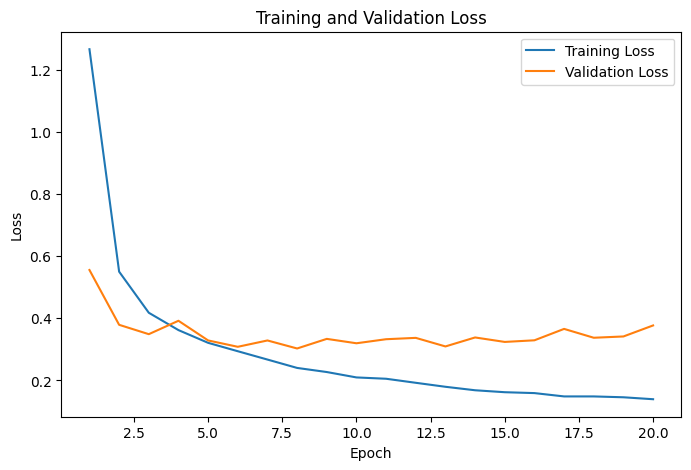

In [1]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

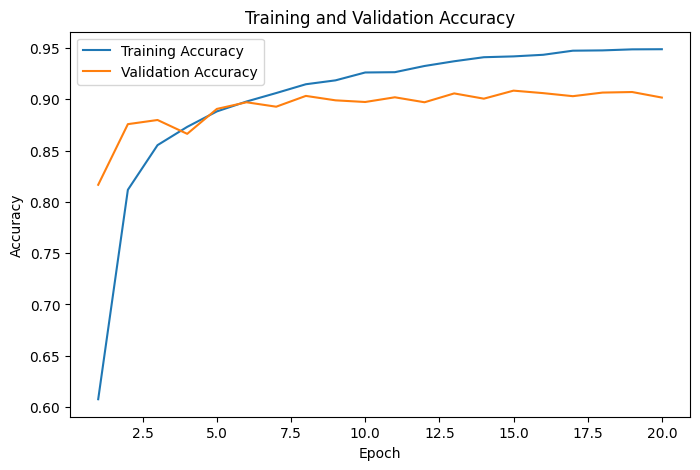

In [2]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

In [3]:
model.load_state_dict(
    torch.load(
        "best_speech_command_cnn.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)

print("Best model loaded.")
print("Best validation accuracy:", best_val_accuracy)

Best model loaded.
Best validation accuracy: 0.9084526059951391


In [4]:
# ============================================================
# STEP — EVALUATE BEST MODEL ON TEST SET
# ============================================================

# Load the best checkpoint
model.load_state_dict(
    torch.load(
        "best_speech_command_cnn.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)

# Evaluation mode
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for mel_batch, label_batch in test_loader:

        mel_batch = mel_batch.to(
            device,
            non_blocking=True
        )

        label_batch = label_batch.to(
            device,
            non_blocking=True
        )

        outputs = model(mel_batch)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == label_batch
        ).sum().item()

        total += label_batch.size(0)

test_accuracy = correct / total

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 0.9028
Test Accuracy: 90.28%


In [5]:
# ============================================================
# STEP — CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for mel_batch, label_batch in test_loader:

        mel_batch = mel_batch.to(
            device,
            non_blocking=True
        )

        outputs = model(mel_batch)

        predictions = outputs.argmax(dim=1)

        y_true.extend(
            label_batch.numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )

# Create confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[405   2   0   3   6   1   0   1   0   1]
 [  1 348   3  17   2   2   0   1   0  31]
 [  0   2 375   4   0   1   5  22  11   5]
 [  4  19   0 353   7   1   0   2   5  15]
 [ 14   3   2   1 380   5   0   4   1   2]
 [  0   1   0   1   6 378   2   4   2   2]
 [  0   3   2   2   2   7 356  19   1   4]
 [  1   1  23   3   2   0  13 347   3   9]
 [  0   0  10   3   0   1   1   3 392   1]
 [  3  33   4   8   1   1   1   2   5 344]]


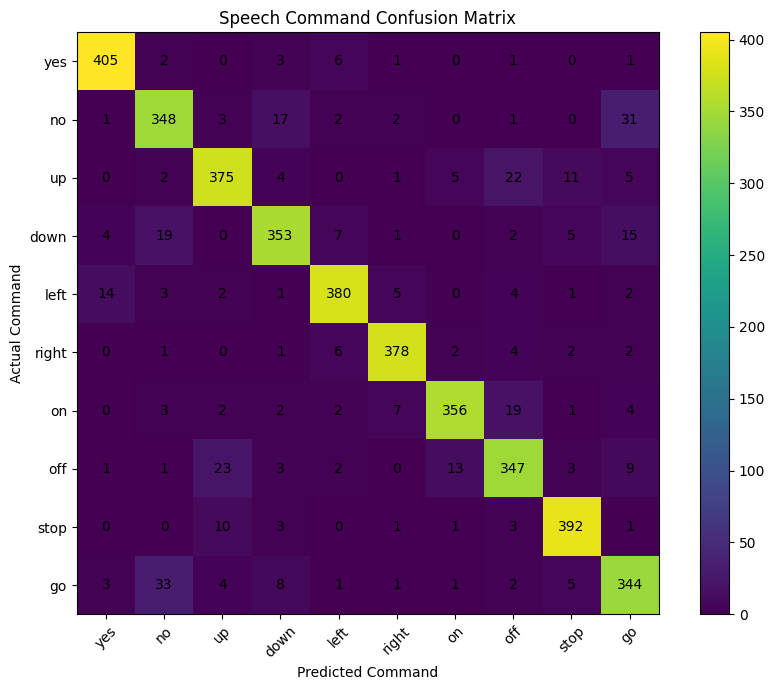

In [6]:
# ============================================================
# STEP — VISUALIZE CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title("Speech Command Confusion Matrix")
plt.xlabel("Predicted Command")
plt.ylabel("Actual Command")

plt.xticks(
    range(len(COMMANDS)),
    COMMANDS,
    rotation=45
)

plt.yticks(
    range(len(COMMANDS)),
    COMMANDS
)

plt.colorbar()

# Write the numbers inside the cells
for i in range(len(COMMANDS)):
    for j in range(len(COMMANDS)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# STEP — PRECISION, RECALL AND F1-SCORE
# ============================================================

from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=COMMANDS,
    digits=4
)

print(report)

              precision    recall  f1-score   support

         yes     0.9463    0.9666    0.9563       419
          no     0.8447    0.8593    0.8519       405
          up     0.8950    0.8824    0.8886       425
        down     0.8937    0.8695    0.8814       406
        left     0.9360    0.9223    0.9291       412
       right     0.9521    0.9545    0.9533       396
          on     0.9418    0.8990    0.9199       396
         off     0.8568    0.8632    0.8600       402
        stop     0.9333    0.9538    0.9434       411
          go     0.8309    0.8557    0.8431       402

    accuracy                         0.9028      4074
   macro avg     0.9031    0.9026    0.9027      4074
weighted avg     0.9032    0.9028    0.9029      4074



In [8]:
# ============================================================
# STEP — SAVE FINAL MODEL
# ============================================================

checkpoint = {
    "model_state_dict": model.state_dict(),
    "commands": COMMANDS,
    "num_classes": len(COMMANDS)
}

torch.save(
    checkpoint,
    "/kaggle/working/speech_command_cnn_final.pth"
)

print("Model saved successfully.")

Model saved successfully.


In [10]:
# ============================================================
# STEP — LOAD FINAL MODEL FOR INFERENCE
# ============================================================

checkpoint = torch.load(
    "/kaggle/working/speech_command_cnn_final.pth",
    map_location=device,
    weights_only=True
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

COMMANDS = checkpoint["commands"]

model = model.to(device)
model.eval()

print("Model loaded.")
print("Commands:", COMMANDS)

Model loaded.
Commands: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']


In [12]:
# ============================================================
# STEP — SINGLE AUDIO INFERENCE
# ============================================================

def predict_command(audio_path):

    # Convert audio into Mel spectrogram
    mel = audio_to_mel(audio_path)

    # Convert NumPy array to PyTorch tensor
    mel = torch.tensor(
        mel,
        dtype=torch.float32
    )

    # Add batch dimension
    mel = mel.unsqueeze(0)

    # Send to GPU
    mel = mel.to(device)

    # Disable gradient calculation
    with torch.no_grad():

        # Get model predictions
        outputs = model(mel)

        # Find class with highest score
        predicted_class = outputs.argmax(dim=1).item()

    predicted_command = COMMANDS[predicted_class]

    return predicted_command

In [14]:
test_audio = "/kaggle/input/datasets/yashdogra/speech-commands/yes/4c6944d6_nohash_3.wav"

prediction = predict_command(test_audio)

print("Predicted command:", prediction)

Predicted command: yes


In [ ]:
model.train()

running_loss = 0.0
correct = 0
total = 0

for mel_batch, label_batch in train_loader:

    mel_batch = mel_batch.to(device)
    label_batch = label_batch.to(device)

    optimizer.zero_grad()

    outputs = model(mel_batch)

    loss = criterion(
        outputs,
        label_batch
    )

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

    predictions = outputs.argmax(dim = 1)

    correct += (predictions == label_batch).sum().item()

    total += label_batch.size(0)


epoch_loss = running_loss / len(train_loader)

epoch_accuracy = correct / total

print("Training loss: ", epoch_loss)
print("Training accuracy: ", epoch_accuracy)

In [ ]:
# How to make Ai voice sound more humane with intentional noise, voice pull,
# ummmm, and other stuff
# add those noises randomly and trained by dataset

# Folder: /kaggle/input
# Folder: /kaggle/input/datasets
# Folder: /kaggle/input/datasets/yashdogra
# Folder: /kaggle/input/datasets/yashdogra/speech-commands
#    LICENSE
#    testing_list.txt
#    README.md
#    validation_list.txt
# Folder: /kaggle/input/datasets/yashdogra/speech-commands/no
#    4c6944d6_nohash_3.wav
#    4e99c1b7_nohash_3.wav
#    97f4c236_nohash_3.wav
#    cb2929ce_nohash_3.wav
#    ca4d5368_nohash_3.wav